# Exploratory Data Analysis (EDA)

## DecodeLabs Data Analytics Internship – Week 2

### Project Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on an e-commerce dataset to understand its structure, identify patterns, analyze distributions, detect outliers, and generate meaningful business insights.

EDA helps transform raw data into useful information by summarizing key characteristics, discovering trends, and highlighting relationships between variables before further analysis or modeling.

## 1. Importing Required Libraries

The following libraries are used for data analysis and visualization.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


## 2. Loading the Dataset

The dataset is loaded into a Pandas DataFrame for exploration and analysis.

In [3]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")

In [4]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## 3. Dataset Overview

Before analyzing the data, it is important to understand the dataset size, structure, column names, and data types.

In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1200, 14)


In [6]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


### Observation

The dataset contains 1200 transaction records and 14 columns representing customer purchases, products, payment methods, order status, pricing information, and referral sources.

The dataset includes both numerical and categorical variables, making it suitable for descriptive and exploratory analysis.

## 4. Missing Value Analysis

Checking the dataset for missing values helps ensure that the analysis is based on complete and reliable information.

In [8]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

### Observation

The dataset contains missing values only in the `CouponCode` column, with 309 missing entries. Since this analysis focuses on understanding patterns and trends, the missing coupon values do not significantly affect the exploratory analysis.

## 5. Descriptive Statistics

Descriptive statistics provide a summary of the numerical variables in the dataset, including measures such as count, mean, standard deviation, minimum, maximum, and quartiles.

In [9]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [10]:
numerical_columns = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice"
]

df[numerical_columns].agg(
    ["count", "mean", "median", "min", "max"]
)

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.00000,1200.000,1200.0000
mean,2.945833,356.41275,5.485,1053.9683
median,3.000000,364.21000,5.000,823.6150
min,1.000000,11.39000,1.000,11.3900
max,5.000000,699.93000,10.000,3456.4000


### Observation

The dataset contains 1200 transaction records.

The average quantity purchased per order is approximately 3 items, while the median quantity is also 3, indicating a balanced distribution of order quantities.

The average unit price is ₹356.41, with product prices ranging from ₹11.39 to ₹699.93.

The average order value is ₹1053.97, while the median order value is ₹823.62. Since the mean is higher than the median, some high-value transactions increase the overall average order value.

Customers typically purchase around 5 items per cart, with cart sizes ranging from 1 to 10 items.

## 6. Transaction Date Range

Understanding the time span of the dataset helps provide context for the analysis.

In [13]:
print("Start Date :", df["Date"].min())
print("End Date   :", df["Date"].max())

Start Date : 2023-01-01 00:00:00
End Date   : 2025-06-30 00:00:00


### Observation

The dataset covers transactions from January 2023 to June 2025, providing more than two years of customer purchasing data for analysis.

## 7. Product Analysis

This section examines the frequency of product purchases to identify the most popular products among customers.

In [15]:
product_counts = df["Product"].value_counts()

product_counts

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

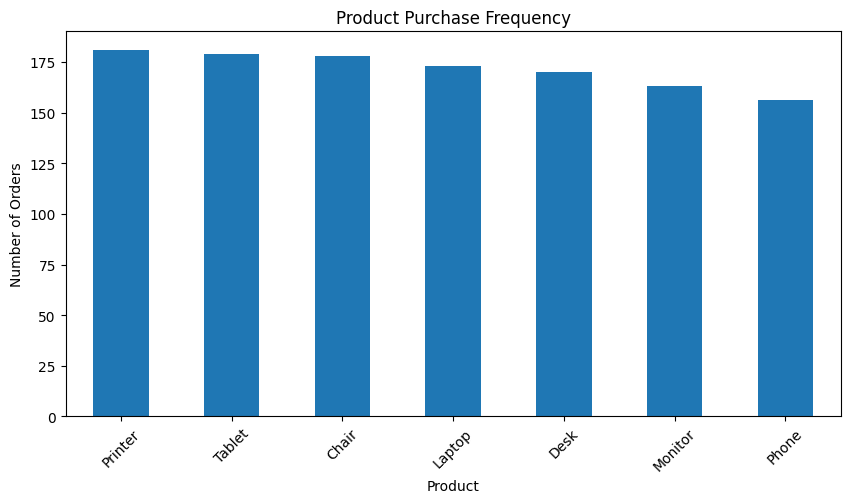

In [16]:
plt.figure(figsize=(10,5))

product_counts.plot(kind="bar")

plt.title("Product Purchase Frequency")
plt.xlabel("Product")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

### Observation

Printers were the most frequently purchased product with 181 transactions, followed closely by Tablets and Chairs. The purchase frequencies across product categories are relatively balanced, indicating consistent customer interest across multiple product types rather than dependence on a single product category.

## 8. Order Status Analysis

Analyzing order status helps understand the proportion of completed, cancelled, pending, and returned orders.

In [17]:
status_counts = df["OrderStatus"].value_counts()

status_counts

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

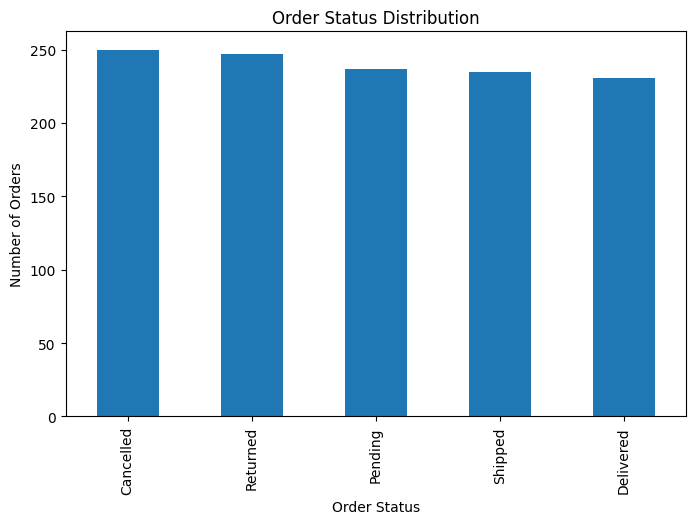

In [18]:
plt.figure(figsize=(8,5))

status_counts.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.show()

### Observation

Order status values are distributed fairly evenly across all categories. Cancelled orders represent the highest count, while Delivered orders represent the lowest count. This distribution suggests that order completion and fulfillment performance may require further investigation to understand customer and operational behavior.

## 9. Payment Method Analysis

This section analyzes customer payment preferences by examining the frequency of different payment methods.

In [19]:
payment_counts = df["PaymentMethod"].value_counts()

payment_counts

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

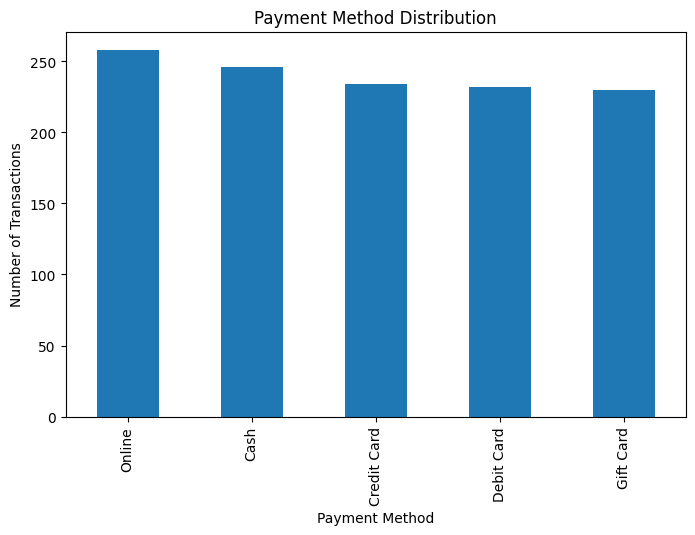

In [20]:
plt.figure(figsize=(8,5))

payment_counts.plot(kind="bar")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.show()

### Observation

Online payments were the most commonly used payment method with 258 transactions. However, all payment methods show relatively similar usage levels, suggesting that customers utilize a variety of payment options rather than relying heavily on a single payment method.

## 10. Referral Source Analysis

Referral sources indicate how customers discovered the platform and can help evaluate marketing effectiveness.

In [21]:
referral_counts = df["ReferralSource"].value_counts()

referral_counts

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

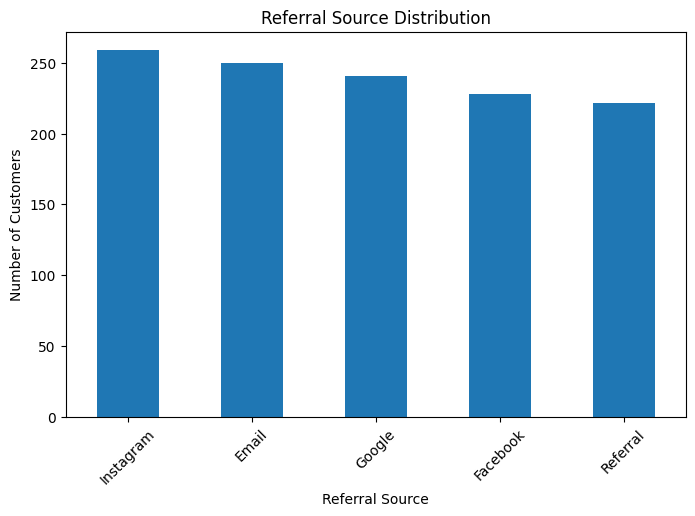

In [22]:
plt.figure(figsize=(8,5))

referral_counts.plot(kind="bar")

plt.title("Referral Source Distribution")
plt.xlabel("Referral Source")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

### Observation

Instagram generated the highest number of customer referrals, followed closely by Email and Google. The results indicate that digital marketing channels contribute significantly to customer acquisition, although no single source dominates the traffic.

## 11. Revenue Analysis by Product

This section examines the average revenue generated by each product category to identify higher-value products.

In [23]:
product_revenue = (
    df.groupby("Product")["TotalPrice"]
      .mean()
      .sort_values(ascending=False)
)

product_revenue

Product
Laptop     1110.558150
Chair      1098.989382
Printer    1080.732652
Monitor    1077.616012
Tablet     1042.284637
Desk        985.058412
Phone       972.579423
Name: TotalPrice, dtype: float64

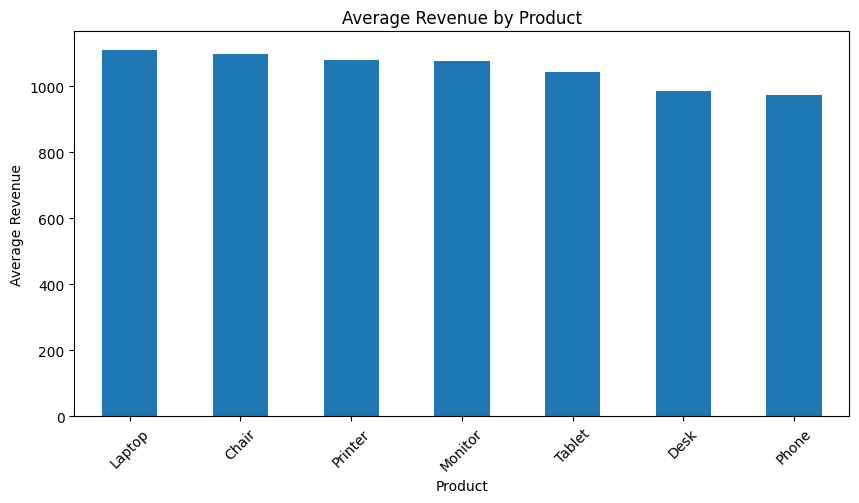

In [24]:
plt.figure(figsize=(10,5))

product_revenue.plot(kind="bar")

plt.title("Average Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Average Revenue")

plt.xticks(rotation=45)

plt.show()

### Observation

Laptops generated the highest average transaction value at approximately ₹1111 per order. Chairs, Printers, and Monitors also produced relatively high average revenues. These products contribute more value per transaction and may represent important revenue-generating categories.

## 12. Distribution Analysis

Distribution analysis helps understand how transaction values are spread across the dataset and whether customer spending patterns are concentrated or widely varied.

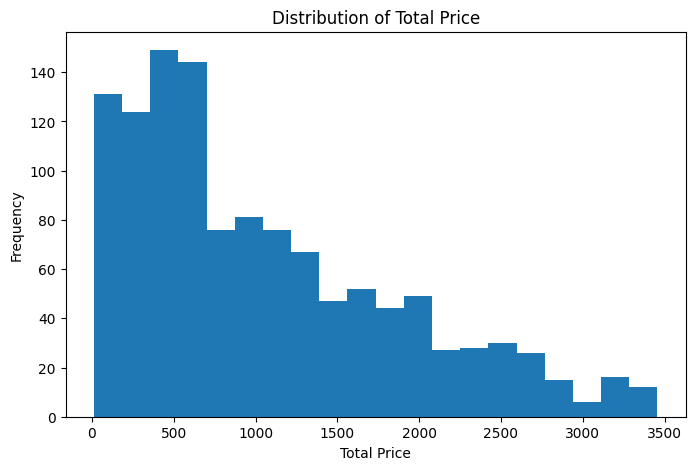

In [30]:
plt.figure(figsize=(8,5))

plt.hist(df["TotalPrice"], bins=20)

plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")

plt.show()

### Observation

Most transactions are concentrated in the lower to middle price ranges, while a smaller number of transactions have significantly higher values.

The distribution appears slightly right-skewed, indicating the presence of some high-value purchases that increase the overall average order value.

## 13. Outlier Detection

Outlier analysis helps identify unusually high or low transaction values that differ significantly from the majority of observations.

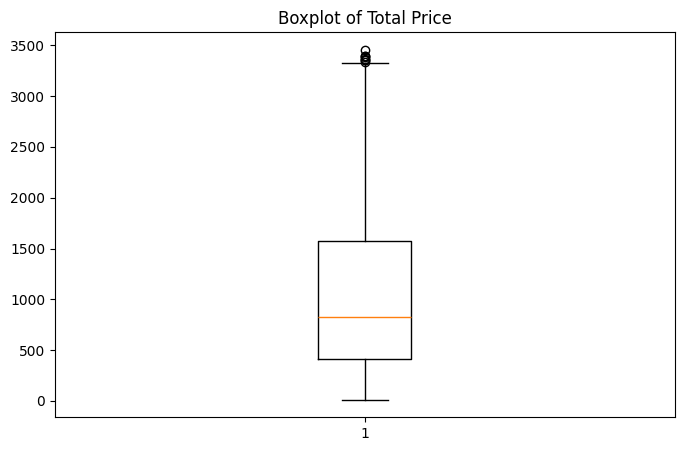

In [31]:
plt.figure(figsize=(8,5))

plt.boxplot(df["TotalPrice"])

plt.title("Boxplot of Total Price")

plt.show()

In [32]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["TotalPrice"] < lower_bound) |
    (df["TotalPrice"] > upper_bound)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 8


### Observation

The boxplot and IQR analysis reveal the presence of a small number of unusually high-value transactions.

These observations may represent bulk purchases or premium product combinations and should be reviewed separately when conducting detailed business analysis.

## 14. Correlation Analysis

Correlation analysis measures the strength and direction of relationships between numerical variables.

In [33]:
correlation_matrix = df[
    [
        "Quantity",
        "UnitPrice",
        "ItemsInCart",
        "TotalPrice"
    ]
].corr()

correlation_matrix

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


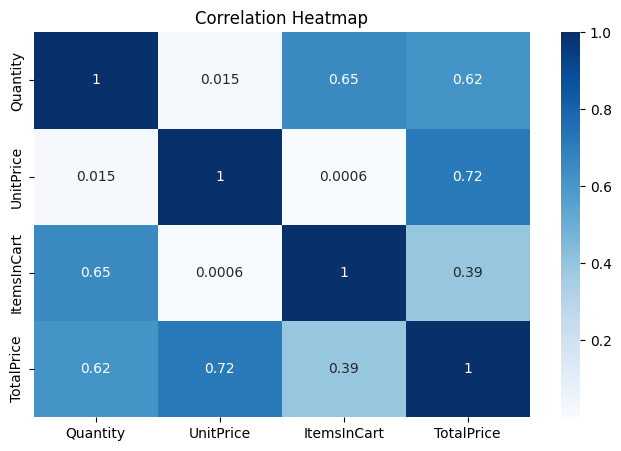

In [34]:
plt.figure(figsize=(8,5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

TotalPrice shows a strong positive relationship with Quantity and UnitPrice because transaction value increases when customers purchase more items or higher-priced products.

Other numerical variables show relatively weaker relationships, indicating that customer purchasing behavior is influenced by multiple factors.

## 15. Key Insights

Based on the exploratory analysis, the following key findings were identified:

1. Printers were the most frequently purchased product, followed closely by Tablets and Chairs.

2. The average order value was approximately ₹1054, indicating moderate customer spending per transaction.

3. Online payments were the most commonly used payment method, although usage was relatively balanced across all payment options.

4. Instagram generated the highest number of customer referrals, suggesting strong performance of digital marketing channels.

5. Laptop purchases generated the highest average transaction value among all product categories.

6. The distribution of transaction values was slightly right-skewed due to a small number of high-value purchases.

7. Correlation analysis confirmed that TotalPrice is strongly influenced by Quantity and UnitPrice.

# Conclusion

This Exploratory Data Analysis project examined an e-commerce transaction dataset to understand customer purchasing behavior, product demand, payment preferences, referral channels, and transaction values.

Through descriptive statistics, visualizations, outlier detection, and correlation analysis, several meaningful business insights were identified. The analysis revealed purchasing trends, customer preferences, and revenue patterns that can support future business decision-making.

Overall, this project provided practical experience in exploring real-world data, interpreting analytical results, and transforming raw information into actionable insights.